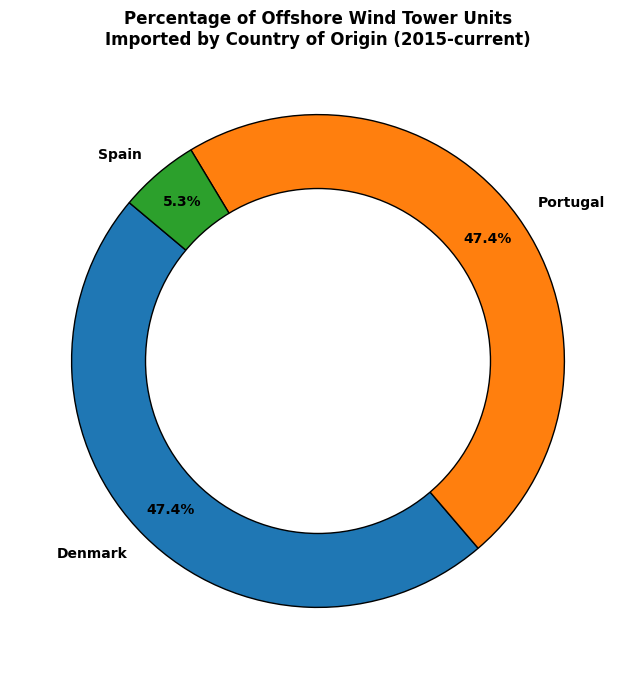

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tower_imports_donut(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)
    
    # Ensure the expected columns exist
    if 'Shipment Origin' not in df.columns or 'Quantity of WTG Towers' not in df.columns:
        raise ValueError("CSV file must contain 'Shipment Origin' and 'Quantity of WTG Towers' columns")
    
    # Aggregate the data by country
    df['Quantity of WTG Towers'] = pd.to_numeric(df['Quantity of WTG Towers'], errors='coerce')  # Convert to numeric
    df = df.dropna(subset=['Quantity of WTG Towers'])  # Drop rows where conversion failed
    country_imports = df.groupby('Shipment Origin')['Quantity of WTG Towers'].sum()
    
    # Compute percentages
    total_blades = country_imports.sum()
    country_percentages = (country_imports / total_blades) * 100
    
    # Sort by largest imports
    country_percentages = country_percentages.sort_values(ascending=False)
    
    # Combine small values into "Others" if needed
    threshold = 2  # Set a threshold (e.g., 2% of total imports)
    small_countries = country_percentages[country_percentages < threshold]
    if not small_countries.empty:
        country_percentages = country_percentages[country_percentages >= threshold]
        country_percentages['Others'] = small_countries.sum()
    
    # Plot the donut chart
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        country_percentages, 
        labels=country_percentages.index, 
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'black'},
        pctdistance=0.85,
        textprops={'color': 'black', 'weight': 'bold'}  # Make text white and bold
    )
    
    # Add the center circle to create the donut shape
    center_circle = plt.Circle((0, 0), 0.70, fc='white', edgecolor='black')
    ax.add_artist(center_circle)
    
    # Set title with bold font
    plt.title('Percentage of Offshore Wind Tower Units\nImported by Country of Origin (2015-current)', fontweight='bold')
    
    # Set other text elements to bold
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # Save the figure as an SVG file
    plt.savefig("figures/tower_imports_1.svg", format="svg", dpi=300)

    # Show plot
    plt.show()

# Example usage
plot_tower_imports_donut('data/towers_panjiba_data.csv')


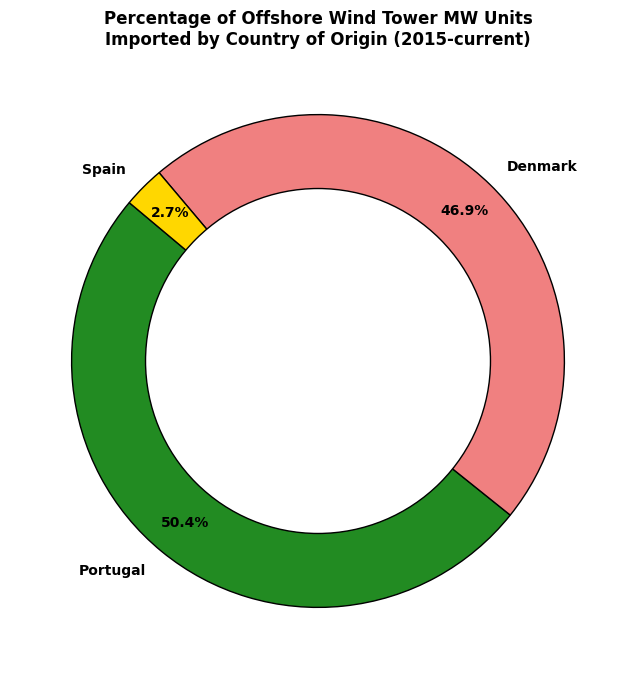

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tower_mw_imports_donut(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)
    
    # Ensure the expected columns exist
    if 'Shipment Origin' not in df.columns or 'Quantity of WTG Towers' not in df.columns or 'NREL category (turbine rating in MW)' not in df.columns:
        raise ValueError("CSV file must contain 'Shipment Origin', 'Quantity of WTG Towers', and 'NREL category (turbine rating in MW)' columns")
    
    # Aggregate the data by country and calculate Blade MW units
    df['Quantity of WTG Towers'] = pd.to_numeric(df['Quantity of WTG Towers'], errors='coerce')  # Convert to numeric
    df['NREL category (turbine rating in MW)'] = pd.to_numeric(df['NREL category (turbine rating in MW)'], errors='coerce')  # Convert to numeric
    df = df.dropna(subset=['Quantity of WTG Towers', 'NREL category (turbine rating in MW)'])  # Drop rows where conversion failed
    
    # Calculate the MW units per country (Quantity of Blades / 3) * NREL category rating
    df['Tower MW'] = df['Quantity of WTG Towers'] * df['NREL category (turbine rating in MW)']
    
    # Aggregate the Blade MW by country
    country_mw_imports = df.groupby('Shipment Origin')['Tower MW'].sum()
    
    # Compute percentages
    total_mw = country_mw_imports.sum()
    country_percentages = (country_mw_imports / total_mw) * 100
    
    # Sort by largest imports
    country_percentages = country_percentages.sort_values(ascending=False)
    
    # Combine small values into "Others" if needed
    threshold = 2  # Set a threshold (e.g., 2% of total imports)
    small_countries = country_percentages[country_percentages < threshold]
    if not small_countries.empty:
        country_percentages = country_percentages[country_percentages >= threshold]
        country_percentages['Others'] = small_countries.sum()
        
    # Color mapping for specific countries
    color_mapping = {
        "Italy": "lavenderblush",
        "Greece": "lightskyblue",
        "France": "powderblue",
        "Denmark": "lightcoral",
        "Canada": "pink",
        "Germany": "darkorange",  # Correcting "dark orange" to "darkorange"
        "Spain": "gold",
        "Portugal": "forestgreen",
        "Netherlands": "lightgrey",
        "South Korea": "beige",
        "Finland": "tab:blue",
        "United Kingdom": "steelblue"
    }
    
    # Assign colors based on the country
    colors = []
    for country in country_percentages.index:
        # If the country is in the color mapping, use the specified color; otherwise, use a default color
        colors.append(color_mapping.get(country, 'gray'))  # 'gray' as a fallback color

    
    # Plot the donut chart
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        country_percentages, 
        labels=country_percentages.index, 
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'black'},
        pctdistance=0.85,
        textprops={'color': 'black', 'weight': 'bold'}, # Make text white and bold
        colors=colors
    )
    
    # Add the center circle to create the donut shape
    center_circle = plt.Circle((0, 0), 0.70, fc='white', edgecolor='black')
    ax.add_artist(center_circle)
    
    # Set title with bold font
    plt.title('Percentage of Offshore Wind Tower MW Units\nImported by Country of Origin (2015-current)', fontweight='bold')

    plt.savefig("figures/tower_imports_2.svg", format="svg", dpi=300)
    # Show plot
    plt.show()

# Example usage
plot_tower_mw_imports_donut('data/towers_panjiba_data.csv')

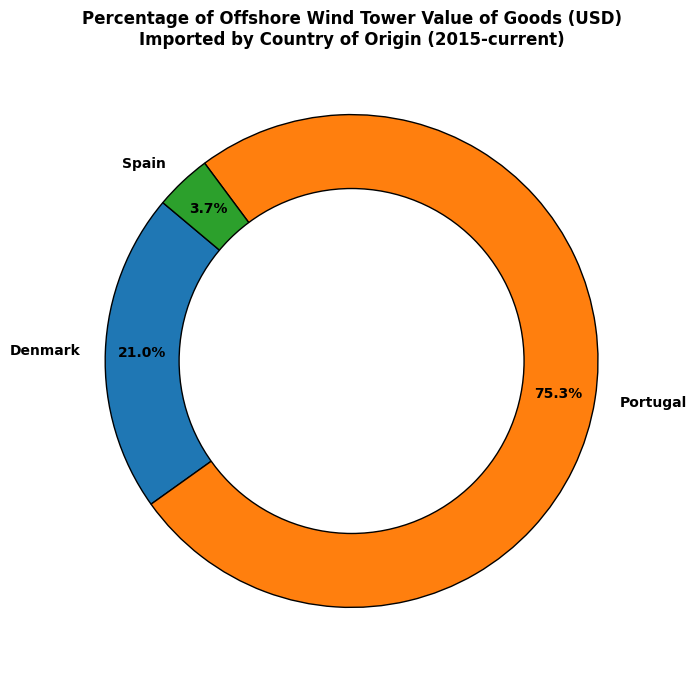

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tower_value_of_goods_imports_donut(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)
    
    # Ensure the expected columns exist
    if 'Shipment Origin' not in df.columns or 'Value of Goods (USD)' not in df.columns:
        raise ValueError("CSV file must contain 'Shipment Origin', 'Quantity of Towers'")
    
    # Aggregate the data by country and calculate Blade MW units
    df['Value of Goods (USD)'] = pd.to_numeric(df['Value of Goods (USD)'], errors='coerce')  # Convert to numeric
    
    # Aggregate the Blade MW by country
    country_mw_imports = df.groupby('Shipment Origin')['Value of Goods (USD)'].sum()
    
    # Compute percentages
    total_mw = country_mw_imports.sum()

    country_percentages = (country_mw_imports / total_mw) * 100
    
    # Plot the donut chart
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        country_percentages, 
        labels=country_percentages.index, 
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'black'},
        pctdistance=0.85,
        textprops={'color': 'black', 'weight': 'bold'}  # Make text white and bold
    )
    
    # Add the center circle to create the donut shape
    center_circle = plt.Circle((0, 0), 0.70, fc='white', edgecolor='black')
    ax.add_artist(center_circle)
    
    # Set title with bold font
    plt.title('Percentage of Offshore Wind Tower Value of Goods (USD)\nImported by Country of Origin (2015-current)', fontweight='bold')
    plt.savefig("figures/tower_imports_3.svg", format="svg", dpi=300)
    # Show plot
    plt.show()

# Example usage
plot_tower_value_of_goods_imports_donut('data/towers_panjiba_data.csv')

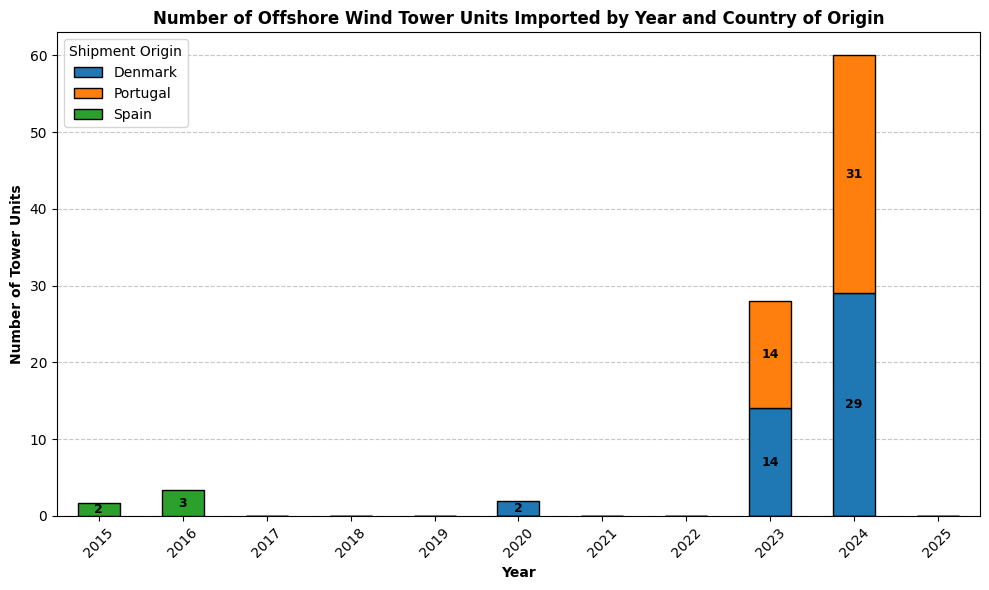

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tower_imports_by_year_and_country(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)  # Assuming the data is comma-separated

    # Convert 'Arrival Date' to datetime format and extract the year
    df['Arrival Date'] = pd.to_datetime(df['Arrival Date'])
    df['Year'] = df['Arrival Date'].dt.year

    # Clean up the 'Quantity of Blades' column (assuming it's in the format like '15 PCS')
    #df['Quantity of WTG Towers'] = df['Quantity of WTG Towers'].str.extract('(\d+)').astype(float)

    # Group by Year and Shipment Origin (Country) and sum the Quantity
    grouped = df.groupby(['Year', 'Shipment Origin'])['Quantity of WTG Towers'].sum().reset_index()

    # Pivot the table for plotting
    all_years = range(2015, 2026)
    pivot_data = grouped.pivot(index='Year', columns='Shipment Origin', values='Quantity of WTG Towers')

    # Ensure all years from 2016 to 2025 are included, even if some years are missing
    pivot_data = pivot_data.reindex(all_years, fill_value=0)

    # Plot the data
    ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), edgecolor='black', zorder = 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder =1)

    # Title and labels
    plt.title('Number of Offshore Wind Tower Units Imported by Year and Country of Origin', fontweight='bold')
    plt.xlabel('Year', fontweight='bold')
    plt.ylabel('Number of Tower Units', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Adding the values in the middle of each bar segment
    for p in ax.patches:
        # Get the x and y coordinates of the bar segment
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height() / 2
        
        # Get the height of the bar segment
        height = p.get_height()

        # Skip labels with value 0
        if height == 0:
            continue
        
        # Get the label value (height of the segment)
        label = f'{height:.0f}'
        
        # Place the label in the center of the bar segment
        ax.text(x, y, label, ha='center', va='center', color='black', fontweight='bold', fontsize=9, zorder = 100)

    plt.savefig("figures/tower_imports_5.svg", format="svg", dpi=300)

    plt.show()

# Test the function with your CSV file
plot_tower_imports_by_year_and_country('data/towers_panjiba_data.csv')


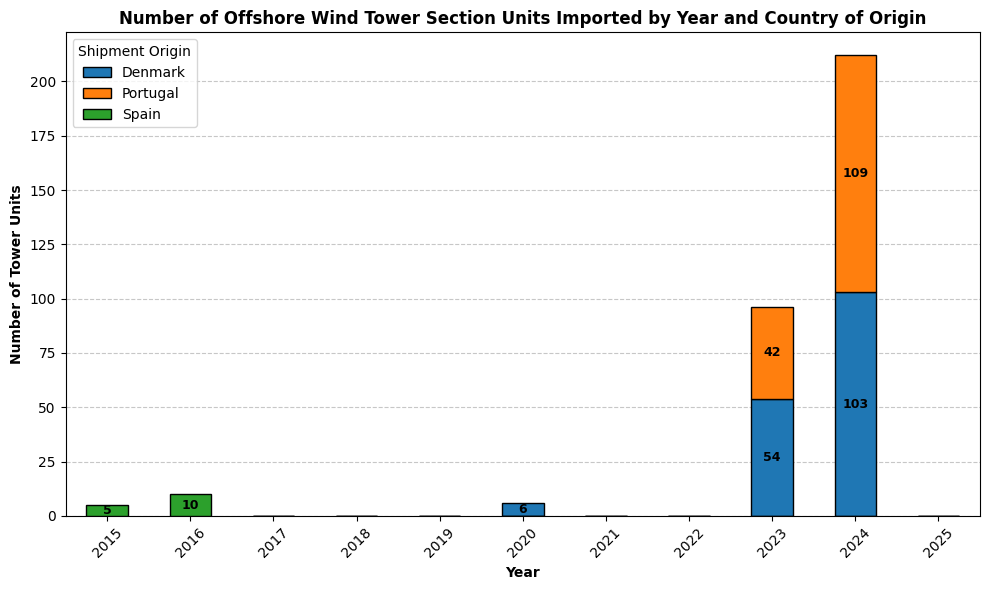

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tower_sections_imports_by_year_and_country(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)  # Assuming the data is comma-separated

    # Convert 'Arrival Date' to datetime format and extract the year
    df['Arrival Date'] = pd.to_datetime(df['Arrival Date'])
    df['Year'] = df['Arrival Date'].dt.year

    # Clean up the 'Quantity of Blades' column (assuming it's in the format like '15 PCS')
    #df['Quantity of WTG Towers'] = df['Quantity of WTG Towers'].str.extract('(\d+)').astype(float)

    # Group by Year and Shipment Origin (Country) and sum the Quantity
    grouped = df.groupby(['Year', 'Shipment Origin'])['Quantity of Tower Sections'].sum().reset_index()

    # Pivot the table for plotting
    all_years = range(2015, 2026)
    pivot_data = grouped.pivot(index='Year', columns='Shipment Origin', values='Quantity of Tower Sections')

    # Ensure all years from 2016 to 2025 are included, even if some years are missing
    pivot_data = pivot_data.reindex(all_years, fill_value=0)

    # Plot the data
    ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), edgecolor='black', zorder = 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder =1)

    # Title and labels
    plt.title('Number of Offshore Wind Tower Section Units Imported by Year and Country of Origin', fontweight='bold')
    plt.xlabel('Year', fontweight='bold')
    plt.ylabel('Number of Tower Units', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Adding the values in the middle of each bar segment
    for p in ax.patches:
        # Get the x and y coordinates of the bar segment
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height() / 2
        
        # Get the height of the bar segment
        height = p.get_height()

        # Skip labels with value 0
        if height == 0:
            continue
        
        # Get the label value (height of the segment)
        label = f'{height:.0f}'
        
        # Place the label in the center of the bar segment
        ax.text(x, y, label, ha='center', va='center', color='black', fontweight='bold', fontsize=9, zorder = 100)

    plt.savefig("figures/tower_imports_8.svg", format="svg", dpi=300)

    plt.show()

# Test the function with your CSV file
plot_tower_sections_imports_by_year_and_country('data/towers_panjiba_data.csv')


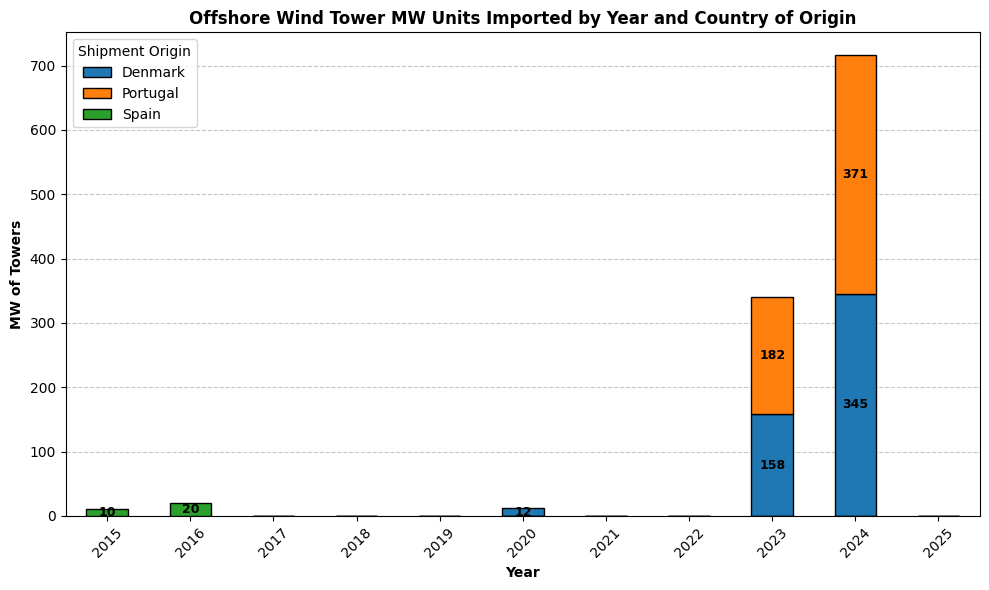

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mw_tower_imports_by_year_and_country(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)  # Assuming the data is comma-separated

    # Convert 'Arrival Date' to datetime format and extract the year
    df['Arrival Date'] = pd.to_datetime(df['Arrival Date'])
    df['Year'] = df['Arrival Date'].dt.year

    # Clean up the 'Quantity of Blades' column (assuming it's in the format like '15 PCS')
    #df['Quantity of WTG Towers'] = df['Quantity of WTG Towers'].str.extract('(\d+)').astype(float)

    # Get the turbine rating (NREL category) for each row
    df['Turbine Rating (MW)'] = df['NREL category (turbine rating in MW)']

    # Calculate MW of blades
    df['MW of Towers'] = df['Quantity of WTG Towers'] * df['Turbine Rating (MW)']

    # Group by Year and Shipment Origin (Country) and sum the MW of Blades
    grouped = df.groupby(['Year', 'Shipment Origin'])['MW of Towers'].sum().reset_index()

    # Pivot the table for plotting
    all_years = range(2015, 2026)
    pivot_data = grouped.pivot(index='Year', columns='Shipment Origin', values='MW of Towers')

    # Ensure all years from 2016 to 2025 are included, even if some years are missing
    pivot_data = pivot_data.reindex(all_years, fill_value=0)

    # Plot the data
    ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), edgecolor='black', zorder = 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder =1)

    # Title and labels
    plt.title('Offshore Wind Tower MW Units Imported by Year and Country of Origin', fontweight='bold')
    plt.xlabel('Year', fontweight='bold')
    plt.ylabel('MW of Towers', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Adding the values in the middle of each bar segment
    for p in ax.patches:
        # Get the x and y coordinates of the bar segment
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height() / 2
        
        # Get the height of the bar segment
        height = p.get_height()

        # Skip labels with value 0
        if height == 0:
            continue
        
        # Get the label value (height of the segment)
        label = f'{height:.0f}'  # Show one decimal point for better precision
        
        # Place the label in the center of the bar segment
        ax.text(x, y, label, ha='center', va='center', color='black', fontweight='bold', fontsize=9, zorder=100)

    plt.savefig("figures/tower_imports_6.svg", format="svg", dpi=300)
    plt.show()

# Test the function with your CSV file
plot_mw_tower_imports_by_year_and_country('data/towers_panjiba_data.csv')

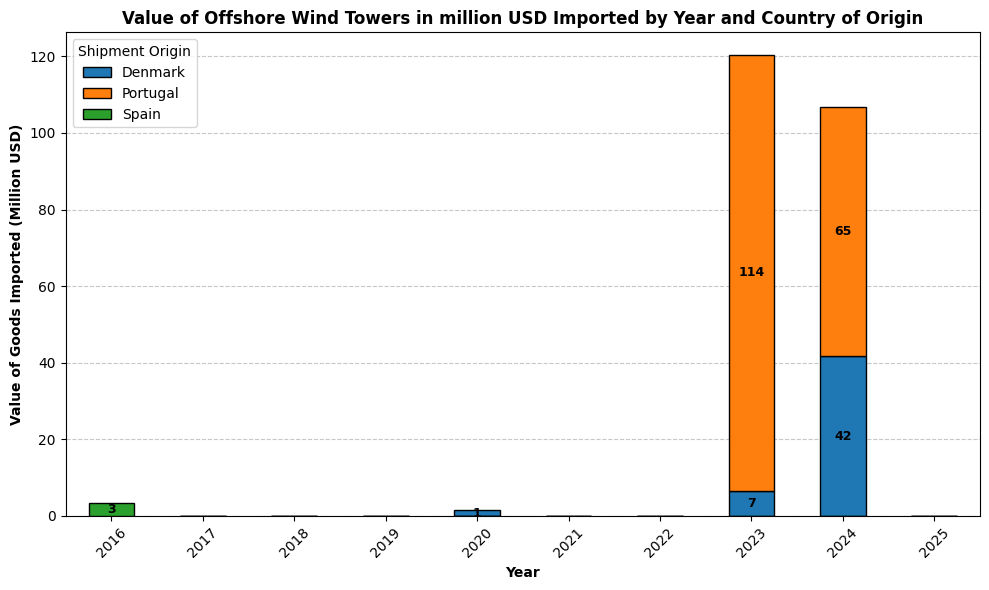

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_tower_imports_by_year_and_country(csv_file):
    # Load the data
    df = pd.read_csv(csv_file)  # Assuming the data is comma-separated

    # Convert 'Arrival Date' to datetime format and extract the year
    df['Arrival Date'] = pd.to_datetime(df['Arrival Date'])
    df['Year'] = df['Arrival Date'].dt.year


    # Group by Year and Shipment Origin (Country) and sum the Quantity
    grouped = df.groupby(['Year', 'Shipment Origin'])['Value of Goods (USD)'].sum().reset_index()

    # Pivot the table for plotting
    all_years = range(2016, 2026)
    pivot_data = grouped.pivot(index='Year', columns='Shipment Origin', values='Value of Goods (USD)')

    # Ensure all years from 2016 to 2025 are included, even if some years are missing
    pivot_data = pivot_data.reindex(all_years, fill_value=0)
    
    pivot_data = pivot_data/1000000

    # Plot the data
    ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), edgecolor='black', zorder = 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7, zorder =1)

    # Title and labels
    plt.title('Value of Offshore Wind Towers in million USD Imported by Year and Country of Origin', fontweight='bold')
    plt.xlabel('Year', fontweight='bold')
    plt.ylabel('Value of Goods Imported (Million USD)', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Adding the values in the middle of each bar segment
    for p in ax.patches:
        # Get the x and y coordinates of the bar segment
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height() / 2
        
        # Get the height of the bar segment
        height = p.get_height()

        # Skip labels with value 0
        if height == 0:
            continue
        
        # Get the label value (height of the segment)
        label = f'{height:.0f}'
        
        # Place the label in the center of the bar segment
        ax.text(x, y, label, ha='center', va='center', color='black', fontweight='bold', fontsize=9, zorder = 100)

    plt.savefig("figures/tower_imports_7.svg", format="svg", dpi=300)
    plt.show()

# Test the function with your CSV file
plot_tower_imports_by_year_and_country('data/towers_panjiba_data.csv')